In [254]:
import pandas as pd
import numpy as np

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

import matplotlib.pyplot as plt

In [255]:
uploaded = files.upload()

Saving Titanic-Dataset.csv to Titanic-Dataset (21).csv


In [256]:
df = pd.read_csv('Titanic-Dataset.csv')

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [257]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [258]:
features = ['Pclass', 'Sex', 'Age', 'Fare']

target = 'Survived'

In [259]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

In [260]:
df['Age'].fillna(df['Age'].median(), inplace=True)

/tmp/ipykernel_416/1933487976.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


In [261]:
X = df[features]

y = df[target]

In [262]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [263]:
model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [264]:
y_pred = model.predict(X_test)

In [265]:
baseline_accuracy = accuracy_score(y_test, y_pred)

print("Baseline Accuracy:", baseline_accuracy)

Baseline Accuracy: 0.7932960893854749


In [266]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.84      0.83       105
           1       0.76      0.73      0.74        74

    accuracy                           0.79       179
   macro avg       0.79      0.78      0.79       179
weighted avg       0.79      0.79      0.79       179



In [267]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

  Feature  Importance
3    Fare    0.333191
1     Sex    0.290210
2     Age    0.278780
0  Pclass    0.097818


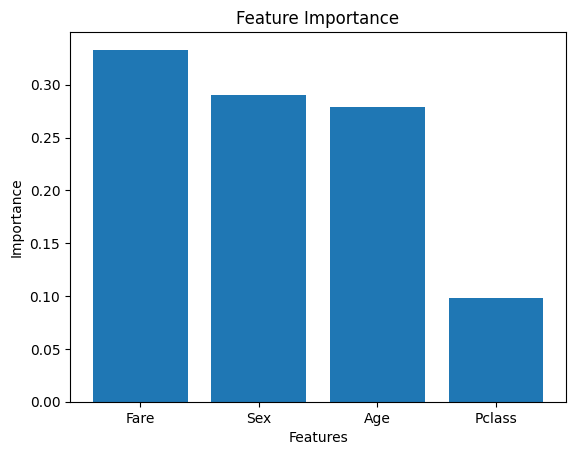

In [268]:
plt.bar(
    importance['Feature'],
    importance['Importance']
)

plt.xlabel("Features")

plt.ylabel("Importance")

plt.title("Feature Importance")

plt.show()

In [269]:
X_new = X.drop(columns=['Sex'])

In [270]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_new,
    y,
    test_size=0.2,
    random_state=42
)

In [271]:
new_model = RandomForestClassifier(random_state=42)

new_model.fit(X_train2, y_train2)

RandomForestClassifier(random_state=42)

In [272]:
y_pred2 = new_model.predict(X_test2)

In [273]:
new_accuracy = accuracy_score(y_test2, y_pred2)

print("New Accuracy:", new_accuracy)

New Accuracy: 0.7262569832402235


In [274]:
print(classification_report(y_test2, y_pred2))

              precision    recall  f1-score   support

           0       0.74      0.83      0.78       105
           1       0.70      0.58      0.64        74

    accuracy                           0.73       179
   macro avg       0.72      0.70      0.71       179
weighted avg       0.72      0.73      0.72       179



In [275]:
print("Baseline Accuracy:", baseline_accuracy)

print("Accuracy After Removing Feature:", new_accuracy)

drop = baseline_accuracy - new_accuracy

print("Performance Drop:", drop)

Baseline Accuracy: 0.7932960893854749
Accuracy After Removing Feature: 0.7262569832402235
Performance Drop: 0.06703910614525144


In [276]:
if new_accuracy < baseline_accuracy:
    print("Model performance decreased after removing important feature.")

else:
    print("Model adapted well even after removing feature.")

Model performance decreased after removing important feature.


# Sprint 2 Reflection

## What I Learned
In this project, I learned how Machine Learning models behave when important features are removed from the dataset. I understood that models may heavily depend on certain features for prediction.

## Challenges Faced
- Identifying the most important feature
- Understanding feature importance
- Comparing model performance

## Key Insight
When the most important feature was removed, model accuracy decreased. However, the model still adapted using remaining features.

## Real-World Understanding
Real-world ML systems must be robust because datasets and business requirements constantly change.

## Future Improvements
- Use better feature engineering
- Try multiple ML algorithms
- Improve robustness of the model